# Chapter 1.1: The Recommendation Problem

## Learning Objectives

By the end of this notebook, you will be able to:

1. Formulate recommendation as a machine learning problem (rating prediction, ranking, CTR prediction)
2. Distinguish between collaborative filtering, content-based, hybrid, and knowledge-based approaches
3. Implement key offline evaluation metrics: AUC, NDCG@K, MAP@K, HitRate@K, MRR
4. Understand the gap between offline and online evaluation
5. Analyze tradeoffs between different problem formulations
6. Apply the correct evaluation metric for a given recommendation task
7. Reason about when each recommendation paradigm is most appropriate

## Prerequisites

- Basic Python and NumPy proficiency
- Familiarity with machine learning concepts (supervised learning, loss functions)
- Basic linear algebra (vectors, matrices, dot products)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part1/chapter_1.1_recommendation_problem.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part1/chapter_1.1_recommendation_problem.ipynb)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, ndcg_score
from collections import defaultdict

np.random.seed(42)

# Plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True

print("All imports successful!")

All imports successful!


## 1. What Is the Recommendation Problem?

At its core, a recommendation system predicts **how much a user will like an item** they haven't interacted with yet. But this seemingly simple goal can be formulated in several distinct ways:

| Formulation | Output | Example |
|---|---|---|
| **Rating Prediction** | $\hat{r}_{ui} \in \mathbb{R}$ | "User Alice will rate Movie X as 4.2 stars" |
| **Top-K Ranking** | Ordered list of K items | "These 10 movies are best for Alice" |
| **CTR Prediction** | $P(\text{click} \mid u, i) \in [0, 1]$ | "Alice has 8.3% chance of clicking this ad" |

### Rating Prediction

Given a user $u$ and item $i$, predict the rating:

$$
\hat{r}_{ui} = f(u, i; \theta)
$$

Optimized via MSE loss:

$$
\mathcal{L}_{\text{MSE}} = \frac{1}{|\mathcal{O}|} \sum_{(u,i) \in \mathcal{O}} (r_{ui} - \hat{r}_{ui})^2
$$

### Top-K Ranking

Rather than predicting exact ratings, produce a ranked list. The key insight: **users care about what's at the top**, not exact scores.

### CTR Prediction

Common in ads and feed ranking. Output a probability via sigmoid:

$$
P(y=1 \mid \mathbf{x}) = \sigma(f(\mathbf{x}; \theta)) = \frac{1}{1 + e^{-f(\mathbf{x}; \theta)}}
$$

Dataset: 200 users, 100 items, 3000 interactions
Rating distribution: mean=3.46, std=0.93
Sparsity: 85.00%


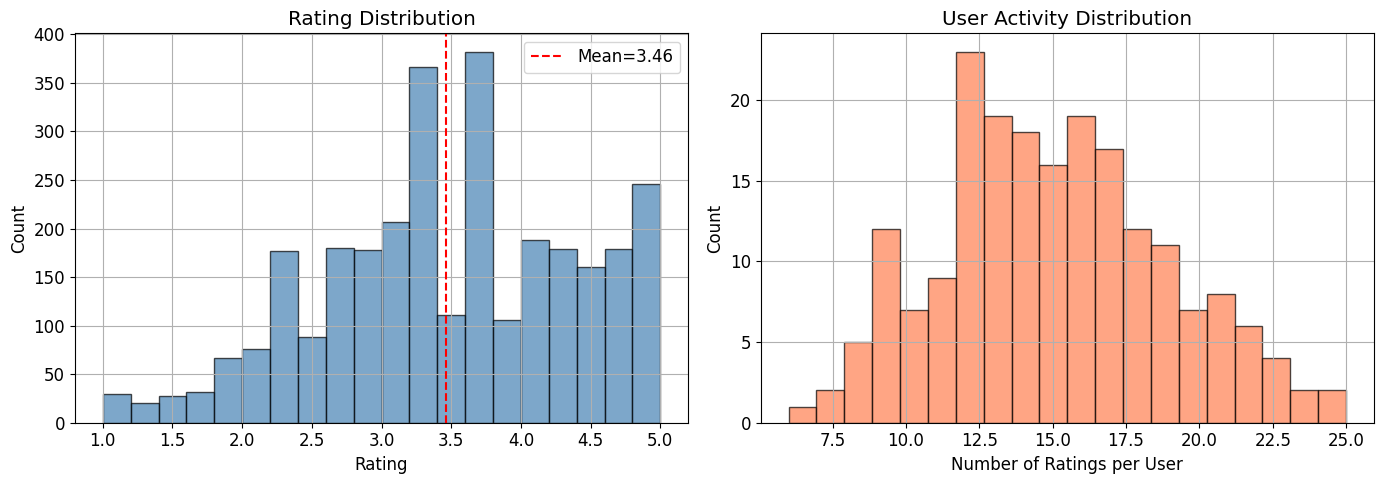

In [2]:
# Generate synthetic MovieLens-style data
n_users = 200
n_items = 100
n_interactions = 3000

# Create random user-item interactions
user_ids = np.random.randint(0, n_users, n_interactions)
item_ids = np.random.randint(0, n_items, n_interactions)
# Ratings with a slight positive bias (like real data)
ratings = np.clip(np.random.normal(3.5, 1.0, n_interactions), 1, 5).round(1)

print(f"Dataset: {n_users} users, {n_items} items, {n_interactions} interactions")
print(f"Rating distribution: mean={ratings.mean():.2f}, std={ratings.std():.2f}")
print(f"Sparsity: {1 - n_interactions / (n_users * n_items):.2%}")

# Visualize rating distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ratings, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('Rating Distribution')
axes[0].axvline(ratings.mean(), color='red', linestyle='--', label=f'Mean={ratings.mean():.2f}')
axes[0].legend()

# Items per user distribution
items_per_user = np.bincount(user_ids, minlength=n_users)
axes[1].hist(items_per_user, bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Number of Ratings per User')
axes[1].set_ylabel('Count')
axes[1].set_title('User Activity Distribution')

plt.tight_layout()
plt.show()

## 2. Taxonomy of Recommendation Systems

### Collaborative Filtering (CF)
Uses the wisdom of the crowd: "Users who agreed in the past will agree in the future."

- **User-based CF**: Find similar users, recommend what they liked
- **Item-based CF**: Find similar items to what user already liked
- **Model-based CF**: Learn latent factors (Matrix Factorization, Neural CF)

> **💡 Concept:** CF only needs the interaction matrix - no item content or user profiles needed. This is both its strength (domain-agnostic) and weakness (cold-start).

### Content-Based Filtering
Recommend items similar to what the user previously liked, based on **item features**.

- Uses item attributes (genre, director, text description)
- Builds a user profile from liked item features
- No cold-start for new items (if features are available)

### Hybrid Methods
Combine CF and content-based:
- **Weighted**: Blend scores from multiple recommenders
- **Switching**: Choose the best method per situation
- **Feature augmentation**: Use one method's output as input to another
- **Meta-level**: One method feeds a model that another uses

### Knowledge-Based
Use explicit domain knowledge or user requirements:
- Constraint-based ("I need a laptop under $1000 with >16GB RAM")
- Case-based reasoning
- Useful for high-stakes, infrequent purchases (cars, houses)

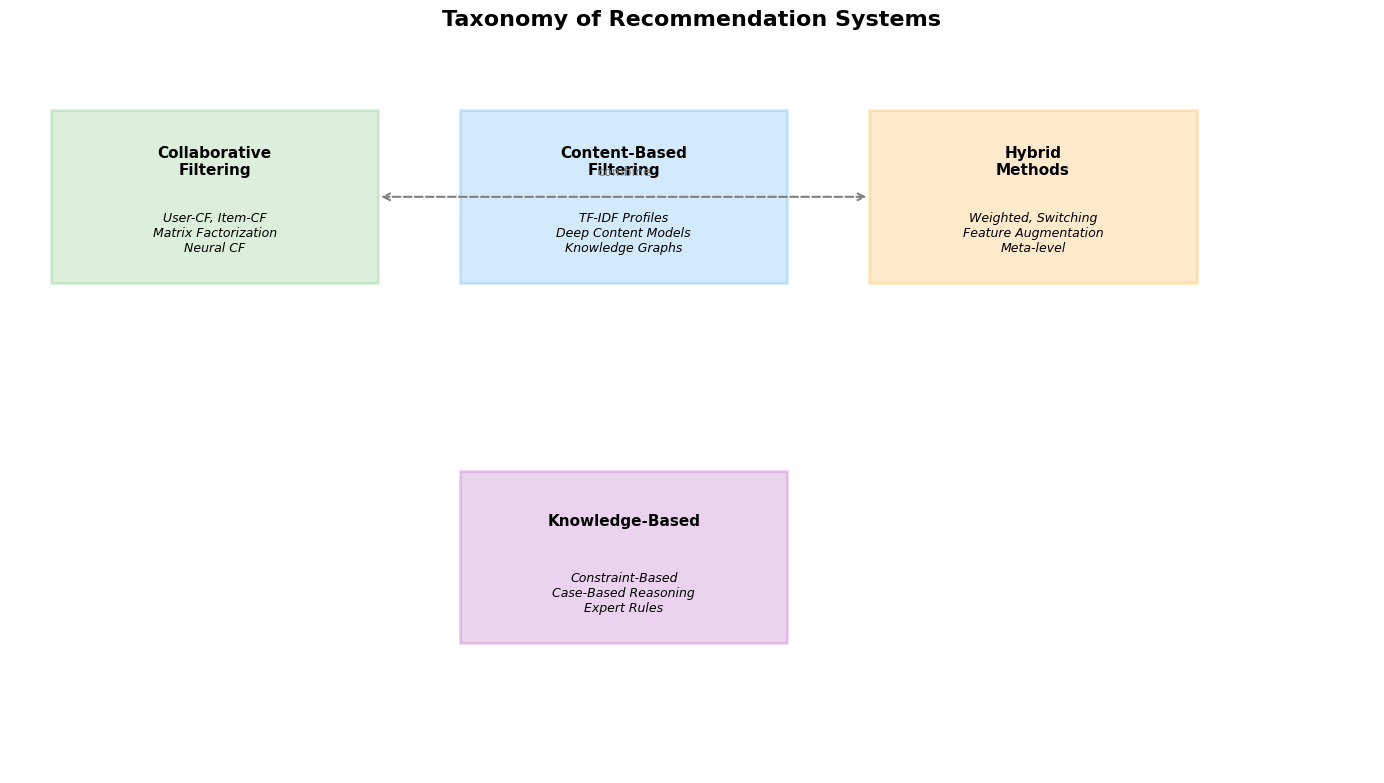

In [3]:
# Visualize the taxonomy
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('Taxonomy of Recommendation Systems', fontsize=16, fontweight='bold', pad=20)

# Main categories as colored boxes
categories = [
    (1.5, 8, 'Collaborative\nFiltering', '#4CAF50', 
     'User-CF, Item-CF\nMatrix Factorization\nNeural CF'),
    (4.5, 8, 'Content-Based\nFiltering', '#2196F3',
     'TF-IDF Profiles\nDeep Content Models\nKnowledge Graphs'),
    (7.5, 8, 'Hybrid\nMethods', '#FF9800',
     'Weighted, Switching\nFeature Augmentation\nMeta-level'),
    (4.5, 3, 'Knowledge-Based', '#9C27B0',
     'Constraint-Based\nCase-Based Reasoning\nExpert Rules')
]

for x, y, title, color, details in categories:
    box = plt.Rectangle((x-1.2, y-1.2), 2.4, 2.4, 
                         facecolor=color, alpha=0.2, edgecolor=color, linewidth=2,
                         transform=ax.transData)
    ax.add_patch(box)
    ax.text(x, y+0.5, title, ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(x, y-0.5, details, ha='center', va='center', fontsize=9, style='italic')

# Arrows from hybrid to CF and content
ax.annotate('', xy=(2.7, 8), xytext=(6.3, 8),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5, ls='--'))
ax.text(4.5, 8.3, 'combine', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

## 3. Evaluation Metrics for Recommendation Systems

Choosing the right metric is crucial. The metric must match the problem formulation.

### 3.1 AUC (Area Under the ROC Curve)

Measures the probability that a randomly chosen positive item is ranked higher than a randomly chosen negative item:

$$
\text{AUC} = \frac{1}{|\mathcal{P}| \cdot |\mathcal{N}|} \sum_{p \in \mathcal{P}} \sum_{n \in \mathcal{N}} \mathbb{1}[\hat{r}_p > \hat{r}_n]
$$

### 3.2 NDCG@K (Normalized Discounted Cumulative Gain)

Measures ranking quality with position-dependent discount:

$$
\text{DCG@K} = \sum_{i=1}^{K} \frac{2^{\text{rel}_i} - 1}{\log_2(i + 1)}
$$

$$
\text{NDCG@K} = \frac{\text{DCG@K}}{\text{IDCG@K}}
$$

### 3.3 MAP@K (Mean Average Precision at K)

$$
\text{AP@K} = \frac{1}{\min(m, K)} \sum_{k=1}^{K} P(k) \cdot \text{rel}(k)
$$

where $m$ is the number of relevant items and $P(k)$ is precision at position $k$.

### 3.4 HitRate@K

Simply: did the relevant item appear in the top-K?

$$
\text{HitRate@K} = \frac{1}{|\mathcal{U}|} \sum_{u \in \mathcal{U}} \mathbb{1}[|\text{TopK}(u) \cap \text{Rel}(u)| > 0]
$$

### 3.5 MRR (Mean Reciprocal Rank)

$$
\text{MRR} = \frac{1}{|\mathcal{U}|} \sum_{u \in \mathcal{U}} \frac{1}{\text{rank}_u}
$$

where $\text{rank}_u$ is the position of the first relevant item.

In [4]:
def auc_score(y_true, y_scores):
    """Compute AUC from scratch."""
    # Get all positive and negative scores
    pos_scores = y_scores[y_true == 1]
    neg_scores = y_scores[y_true == 0]
    
    n_pos = len(pos_scores)
    n_neg = len(neg_scores)
    
    if n_pos == 0 or n_neg == 0:
        return 0.5
    
    # Count pairs where positive score > negative score
    count = 0
    for ps in pos_scores:
        count += np.sum(ps > neg_scores) + 0.5 * np.sum(ps == neg_scores)
    
    return count / (n_pos * n_neg)


def dcg_at_k(relevances, k):
    """Compute DCG@K."""
    relevances = np.array(relevances)[:k]
    if len(relevances) == 0:
        return 0.0
    discounts = np.log2(np.arange(2, len(relevances) + 2))
    return np.sum((2**relevances - 1) / discounts)


def ndcg_at_k(relevances, k):
    """Compute NDCG@K."""
    actual_dcg = dcg_at_k(relevances, k)
    # Ideal: sort relevances in descending order
    ideal_relevances = sorted(relevances, reverse=True)
    ideal_dcg = dcg_at_k(ideal_relevances, k)
    if ideal_dcg == 0:
        return 0.0
    return actual_dcg / ideal_dcg


def ap_at_k(relevant_items, ranked_list, k):
    """Compute Average Precision at K."""
    relevant_set = set(relevant_items)
    hits = 0
    sum_precision = 0.0
    
    for i, item in enumerate(ranked_list[:k]):
        if item in relevant_set:
            hits += 1
            sum_precision += hits / (i + 1)
    
    if len(relevant_set) == 0:
        return 0.0
    return sum_precision / min(len(relevant_set), k)


def hit_rate_at_k(relevant_items, ranked_list, k):
    """Compute HitRate@K."""
    relevant_set = set(relevant_items)
    top_k = set(ranked_list[:k])
    return 1.0 if len(relevant_set & top_k) > 0 else 0.0


def mrr(relevant_items, ranked_list):
    """Compute Reciprocal Rank."""
    relevant_set = set(relevant_items)
    for i, item in enumerate(ranked_list):
        if item in relevant_set:
            return 1.0 / (i + 1)
    return 0.0


# Demo with example data
print("=== Metric Demonstrations ===")
print()

# AUC example
y_true = np.array([1, 1, 0, 0, 1, 0, 1, 0])
y_scores = np.array([0.9, 0.7, 0.4, 0.3, 0.8, 0.2, 0.6, 0.1])
print(f"AUC (ours): {auc_score(y_true, y_scores):.4f}")
print(f"AUC (sklearn): {roc_auc_score(y_true, y_scores):.4f}")
print()

# NDCG example
relevances = [3, 2, 0, 1, 0]  # Relevance scores at each position
print(f"NDCG@3 (ours): {ndcg_at_k(relevances, 3):.4f}")
print(f"NDCG@5 (ours): {ndcg_at_k(relevances, 5):.4f}")
print()

# MAP example
relevant = [1, 3, 5, 7]  # Relevant item IDs
ranked = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  # Predicted ranking
print(f"AP@5: {ap_at_k(relevant, ranked, 5):.4f}")
print(f"AP@10: {ap_at_k(relevant, ranked, 10):.4f}")
print()

# HitRate and MRR
print(f"HitRate@3: {hit_rate_at_k(relevant, ranked, 3):.4f}")
print(f"HitRate@1: {hit_rate_at_k(relevant, ranked, 1):.4f}")
print(f"MRR: {mrr(relevant, ranked):.4f}")

=== Metric Demonstrations ===

AUC (ours): 1.0000
AUC (sklearn): 1.0000

NDCG@3 (ours): 0.9468
NDCG@5 (ours): 0.9926

AP@5: 0.5667
AP@10: 0.7095

HitRate@3: 1.0000
HitRate@1: 1.0000
MRR: 1.0000


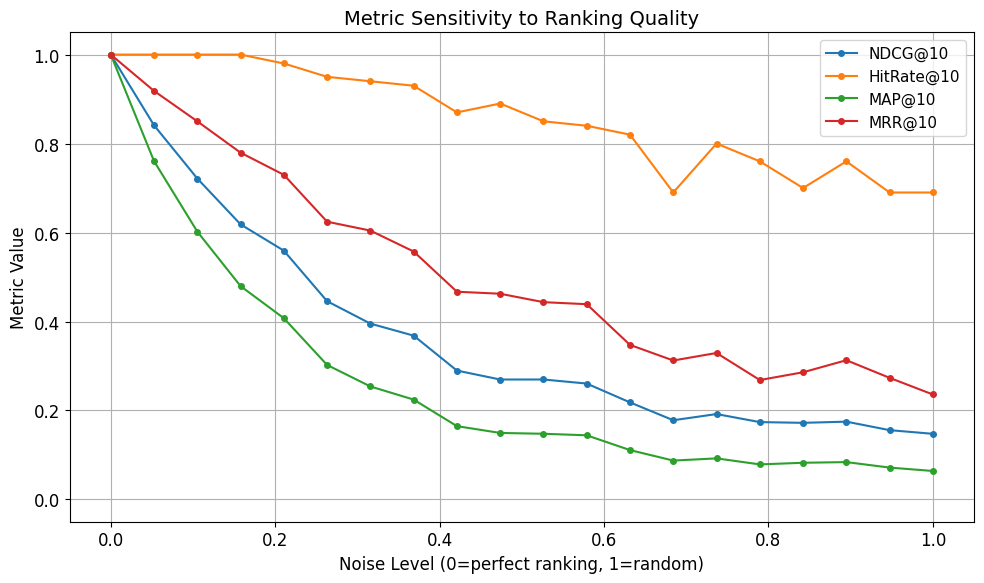

In [5]:
# Visualize how metrics behave with different ranking quality
np.random.seed(42)

n_items_eval = 50
n_relevant = 5
k_values = [1, 3, 5, 10, 20, 50]

# Simulate rankings from "perfect" to "random"
# noise_level controls how much we shuffle the ideal ranking
noise_levels = np.linspace(0, 1, 20)
metrics_by_noise = {'NDCG': [], 'HitRate': [], 'MAP': [], 'MRR': []}

for noise in noise_levels:
    ndcgs, hrs, maps, mrrs = [], [], [], []
    for _ in range(100):  # Average over trials
        relevant_set = list(range(n_relevant))
        # Create a ranking: relevant items first, then noise shuffles positions
        ideal = list(range(n_items_eval))
        # Add noise by random swaps
        ranking = ideal.copy()
        n_swaps = int(noise * n_items_eval * 2)
        for _ in range(n_swaps):
            i, j = np.random.randint(0, n_items_eval, 2)
            ranking[i], ranking[j] = ranking[j], ranking[i]
        
        K = 10
        # Binary relevances for NDCG
        rels = [1 if item in relevant_set else 0 for item in ranking]
        ndcgs.append(ndcg_at_k(rels, K))
        hrs.append(hit_rate_at_k(relevant_set, ranking, K))
        maps.append(ap_at_k(relevant_set, ranking, K))
        mrrs.append(mrr(relevant_set, ranking))
    
    metrics_by_noise['NDCG'].append(np.mean(ndcgs))
    metrics_by_noise['HitRate'].append(np.mean(hrs))
    metrics_by_noise['MAP'].append(np.mean(maps))
    metrics_by_noise['MRR'].append(np.mean(mrrs))

fig, ax = plt.subplots(figsize=(10, 6))
for metric_name, values in metrics_by_noise.items():
    ax.plot(noise_levels, values, marker='o', markersize=4, label=f'{metric_name}@10')

ax.set_xlabel('Noise Level (0=perfect ranking, 1=random)', fontsize=12)
ax.set_ylabel('Metric Value', fontsize=12)
ax.set_title('Metric Sensitivity to Ranking Quality', fontsize=14)
ax.legend(fontsize=11)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

> **💡 Concept:** Notice how different metrics have different sensitivities to noise. MRR and HitRate are more "forgiving" because they only care about the first relevant item. NDCG and MAP capture the quality of the entire ranking. Choose your metric based on what matters for your product.

## 4. Offline vs Online Evaluation

| Aspect | Offline | Online |
|---|---|---|
| **Data** | Historical logs | Live traffic |
| **Metrics** | NDCG, AUC, MAP | CTR, Revenue, Session Time |
| **Speed** | Fast (minutes/hours) | Slow (days/weeks) |
| **Cost** | Low | High (user experience risk) |
| **Bias** | Exposure/selection bias | Novelty/primacy effects |
| **Method** | Train/test split | A/B test, interleaving |

> **⚠️ Common Pitfall:** A model that improves offline metrics does NOT always improve online metrics. Offline evaluation has *selection bias*: we only observe ratings for items that were previously recommended/discovered. Items that a new model would recommend may have no historical data.

> **🔑 Pro Tip:** In industry, offline evaluation is used as a filter to decide which models are worth A/B testing. The correlation between offline and online metrics is often weak, so always validate online before a full launch.

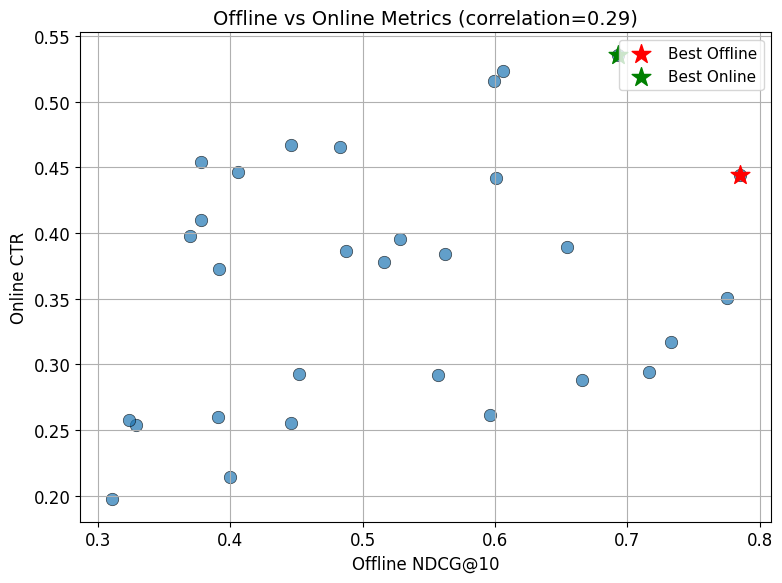

Best offline model index: 11, NDCG=0.785, CTR=0.444
Best online model index: 25, NDCG=0.693, CTR=0.536


In [6]:
# Simulate the offline-online gap
np.random.seed(42)

n_models = 30
# Offline NDCG scores for 30 candidate models
offline_ndcg = np.random.uniform(0.3, 0.8, n_models)
# Online CTR: correlated but noisy (this is realistic!)
online_ctr = 0.3 * offline_ndcg + 0.7 * np.random.uniform(0.1, 0.5, n_models)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(offline_ndcg, online_ctr, s=80, alpha=0.7, edgecolors='black', linewidth=0.5)

# Highlight cases where offline winner != online winner
best_offline = np.argmax(offline_ndcg)
best_online = np.argmax(online_ctr)
ax.scatter(offline_ndcg[best_offline], online_ctr[best_offline], 
           s=200, color='red', marker='*', zorder=5, label='Best Offline')
ax.scatter(offline_ndcg[best_online], online_ctr[best_online], 
           s=200, color='green', marker='*', zorder=5, label='Best Online')

# Correlation
corr = np.corrcoef(offline_ndcg, online_ctr)[0, 1]
ax.set_xlabel('Offline NDCG@10', fontsize=12)
ax.set_ylabel('Online CTR', fontsize=12)
ax.set_title(f'Offline vs Online Metrics (correlation={corr:.2f})', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Best offline model index: {best_offline}, NDCG={offline_ndcg[best_offline]:.3f}, CTR={online_ctr[best_offline]:.3f}")
print(f"Best online model index: {best_online}, NDCG={offline_ndcg[best_online]:.3f}, CTR={online_ctr[best_online]:.3f}")

## 5. When to Use Which Approach?

| Scenario | Best Approach | Reason |
|---|---|---|
| Many users, many interactions | Collaborative Filtering | Rich interaction signal |
| New platform, few users | Content-Based | No interaction data needed |
| Cold-start + warm users | Hybrid | Leverage both signals |
| Complex requirements | Knowledge-Based | Explicit constraints |
| Feed ranking (News, Social) | CTR Prediction | Immediate engagement signal |
| E-commerce "You may like" | Top-K Ranking | Browsing context |

> **🔑 Pro Tip:** In modern industry systems (Meta, Google, TikTok), the answer is almost always **hybrid**: deep learning models that combine collaborative signals, content features, context, and sequential behavior.

---

## Exercises

### 🏋️ Exercise 1: Implement NDCG@K from Scratch and Compare with sklearn

Implement a full `ndcg_at_k_v2` that handles multiple queries/users and compare with `sklearn.metrics.ndcg_score`.

In [7]:
def ndcg_at_k_v2(y_true_batch, y_score_batch, k):
    """
    Compute mean NDCG@K over a batch of queries.
    
    Args:
        y_true_batch: list of arrays, each containing relevance scores
        y_score_batch: list of arrays, each containing predicted scores
        k: cutoff position
    
    Returns:
        Mean NDCG@K across all queries
    """
    # TODO: Implement this function
    # Hint 1: For each query, sort items by predicted score (descending)
    # Hint 2: Get the relevances in the predicted order
    # Hint 3: Use dcg_at_k() and compare with ideal ordering
    # Hint 4: Average across all queries
    pass


# Test data
np.random.seed(42)
n_queries = 5
n_docs = 10

y_true_batch = [np.random.randint(0, 4, n_docs) for _ in range(n_queries)]
y_score_batch = [np.random.random(n_docs) for _ in range(n_queries)]

# Your implementation
# our_ndcg = ndcg_at_k_v2(y_true_batch, y_score_batch, k=5)

# Compare with sklearn
# sklearn_ndcg = ndcg_score(np.array(y_true_batch), np.array(y_score_batch), k=5)

# print(f"Our NDCG@5: {our_ndcg:.6f}")
# print(f"sklearn NDCG@5: {sklearn_ndcg:.6f}")
# print(f"Difference: {abs(our_ndcg - sklearn_ndcg):.8f}")

### 🏋️ Exercise 2: Implement MAP@K

Implement Mean Average Precision for multiple users.

In [8]:
def map_at_k(relevant_items_batch, ranked_lists_batch, k):
    """
    Compute Mean Average Precision at K.
    
    Args:
        relevant_items_batch: list of lists, each containing relevant item IDs for a user
        ranked_lists_batch: list of lists, each containing ranked item IDs
        k: cutoff position
    
    Returns:
        MAP@K value
    """
    # TODO: Implement this function
    # Hint: Use the ap_at_k function defined above
    pass


# Test
# relevant_batch = [[1, 3, 5], [2, 4], [1, 2, 3, 4, 5]]
# ranked_batch = [[1, 2, 3, 4, 5], [5, 4, 3, 2, 1], [5, 3, 1, 2, 4]]
# print(f"MAP@3: {map_at_k(relevant_batch, ranked_batch, 3):.4f}")
# print(f"MAP@5: {map_at_k(relevant_batch, ranked_batch, 5):.4f}")

### 🏋️ Exercise 3: Metric Comparison on Synthetic Recommenders

Create three synthetic recommenders (random, popularity-based, and an "oracle") and compare their evaluation metrics.

In [9]:
def generate_test_scenario(n_users=50, n_items=100, n_relevant_per_user=5):
    """Generate a test scenario with known relevant items per user."""
    np.random.seed(42)
    relevant_items = {}
    item_popularity = np.random.power(0.5, n_items)  # Power-law popularity
    
    for u in range(n_users):
        # Users tend to like popular items more
        probs = item_popularity / item_popularity.sum()
        rel = np.random.choice(n_items, n_relevant_per_user, replace=False, p=probs)
        relevant_items[u] = rel.tolist()
    
    return relevant_items, item_popularity


# TODO: Implement three recommenders and compare metrics
# 1. Random recommender: shuffles items randomly
# 2. Popularity recommender: ranks by item_popularity
# 3. Oracle recommender: places relevant items at top, rest random
#
# For each recommender, compute: NDCG@10, HitRate@10, MAP@10, MRR
# Create a bar chart comparing the three recommenders across metrics

# relevant_items, popularity = generate_test_scenario()
# ... your code here ...

## Summary

In this notebook, we covered:

1. **Three problem formulations**: rating prediction (regression), top-K ranking (learning-to-rank), and CTR prediction (binary classification)
2. **Four recommendation paradigms**: collaborative filtering, content-based, hybrid, and knowledge-based
3. **Five evaluation metrics**: AUC, NDCG@K, MAP@K, HitRate@K, MRR - each with different sensitivities
4. **Offline vs online evaluation**: the importance of A/B testing and the offline-online gap

### Key Takeaways

- The choice of problem formulation drives everything: model architecture, loss function, and evaluation metric
- Ranking metrics (NDCG, MAP) are generally more aligned with user experience than pointwise metrics (MSE, AUC)
- Offline metrics are necessary but not sufficient; always validate with online experiments

### Next Up

In **Chapter 1.2**, we'll dive deep into user-item interaction data: how it's structured, its properties, and how to properly split it for evaluation.